## Feature Cleaning & Redundancy Reduction for Stop-Level Modeling

### i. Imports and Thread Configuration

We start by loading the core libraries used for data processing in this notebook:
pandas, NumPy, Polars, and GeoPandas.  
Before importing numerical libraries such as NumPy or scikit-learn, we also
explicitly limit the number of BLAS and OpenMP threads.  
This prevents oversubscription on multi-core CPUs and ensures stable, predictable
performance during data loading, feature engineering, and model training.


In [ ]:
import os
import pandas as pd
import numpy as np
import polars as pl
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

# Set before importing numpy/pandas/sklearn
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["OPENBLAS_NUM_THREADS"] = "4"
os.environ["NUMEXPR_NUM_THREADS"] = "4"

### ii. Load Stop-Level Features and Ward Context

Here we load the full stop-level feature dataset produced in the previous
notebook, along with the ward-level spatial–temporal dataset containing Gini
inequality, service-per-capita, and service rank metrics.

We then merge these ward attributes into the stop-level data.  
Because the ward dataset is aggregated at ward resolution, this join does not
inflate the number of rows and simply enriches each stop with additional
contextual indicators.

In [ ]:
# Load previously generated stop-level features
# (full dataset, not test-mode)
final_df = pd.read_csv('/home/dataopske/Desktop/jav/data/training_data/stop_features_complete.csv')

# Load ward-level spatial-temporal dataset
df3 = pd.read_parquet('/home/dataopske/Desktop/jav/data/processed/wards_full_gdf(with_spatial_temporal_gini).parquet')

# Merge ward metrics into stop-level features
# We group by ward and take the first row to avoid expanding rows
final_df1 = final_df.merge(
    df3[['ward', 'subcounty_gini', 'trips_per_1k_pop_per_hour', 'service_rank_overall']]
        .groupby('ward')
        .first(),
    on='ward',
    how='left'
)

### iii. Correlation Heatmap (Top-Variance Features)

The full correlation matrix contains many low-variance features that add noise
and make the heatmap difficult to interpret. To improve clarity, we compute
feature variances and retain only the top 50% most variable columns. These
features carry the most meaningful signal for correlation analysis.

We then compute a reduced correlation matrix and visualize it using a
perceptually uniform colormap (`Spectral_r`), which produces smoother gradients
and clearer structure in high-dimensional data. This allows us to identify
feature relationships without clutter from low-information variables.


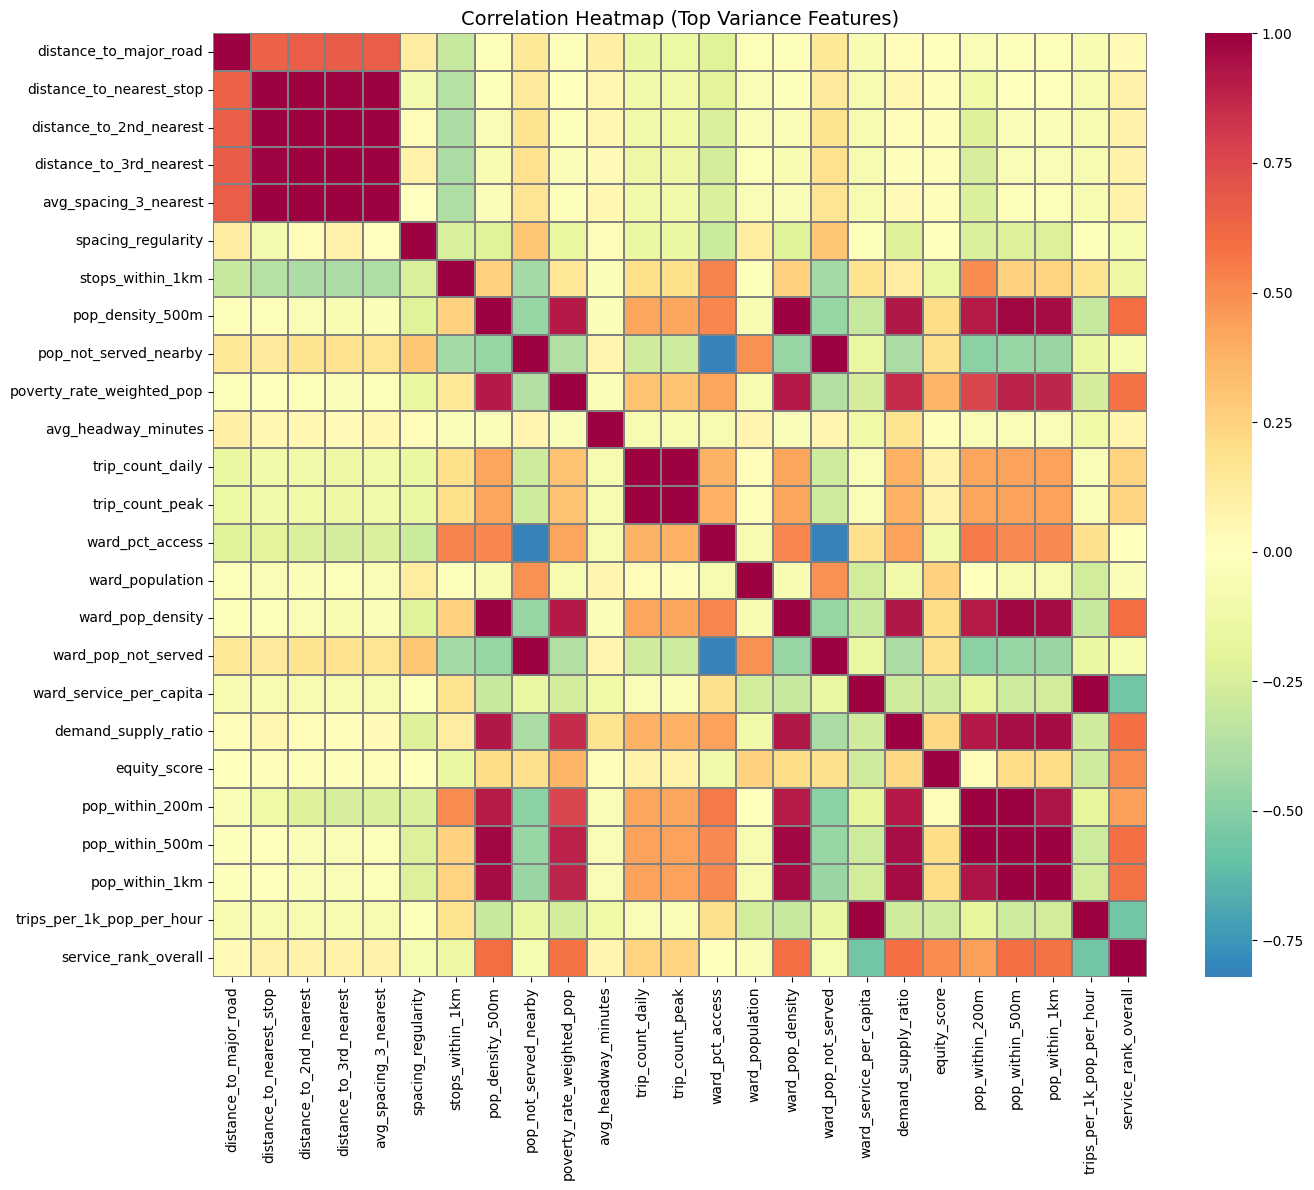

In [ ]:
# Keep only columns with decent variance
# Compute correlation matrix (Pearson by default; use method='spearman' for rank-based) 
corr_matrix = final_df1.corr(numeric_only=True) # numeric_only=True skips non-numeric cols

# Keep only columns with decent variance
var = final_df1.var(numeric_only=True)
top_features = var[var > var.quantile(0.5)].index.tolist()  # top 50% variance

corr_top = final_df1[top_features].corr(numeric_only=True)

plt.figure(figsize=(14, 12))

# Suggest a cleaner palette → 'rocket_r' or 'Spectral_r'
sns.heatmap(
    corr_top,
    cmap='Spectral_r',   # smoother, readable, perceptually uniform
    center=0,
    annot=False,
    linewidths=0.2,
    linecolor="gray"
)

plt.title("Correlation Heatmap (Top Variance Features)", fontsize=14)
plt.tight_layout()
plt.show()



### iv. Correlation With Target Variable

To understand which features are most directly associated with the target label
(`is_good_stop`), we extract the correlation of every numeric feature with the
target and sort them in descending order. This barplot provides a quick,
human-readable ranking of which variables show the strongest linear relationship
to the label.

Unlike the full correlation matrix, this view is focused solely on the
predictive signal. It highlights which spatial, service, population, or traffic
features may be most informative for downstream modeling.


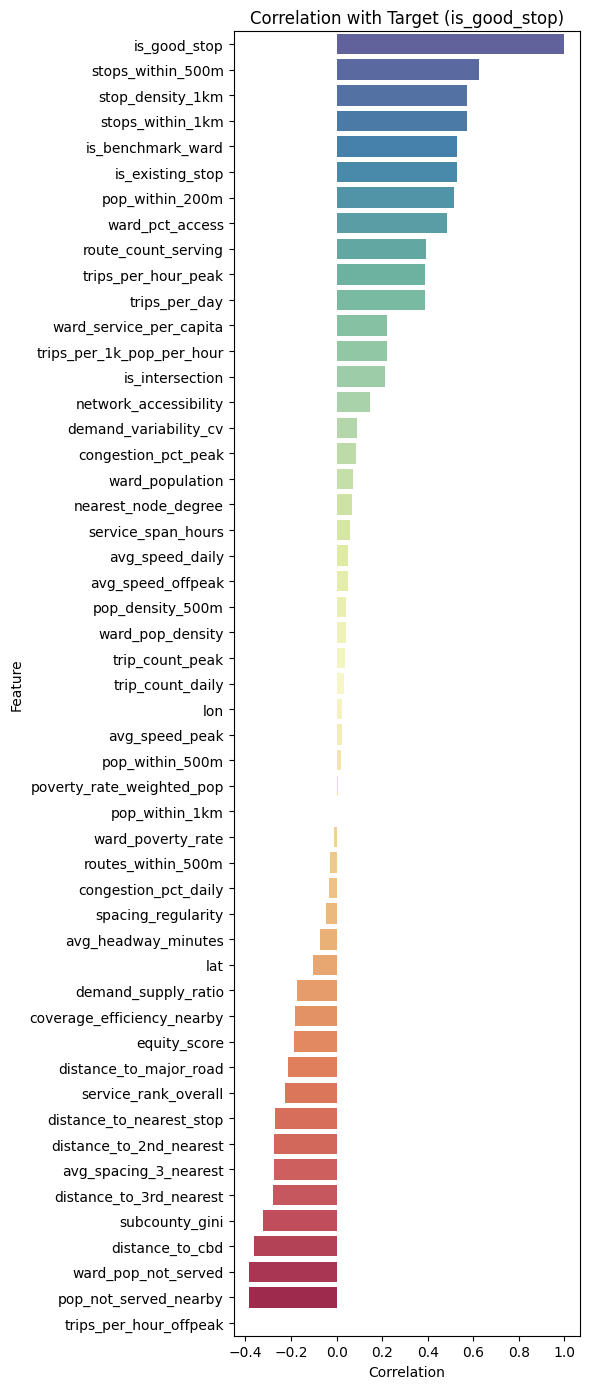

In [ ]:
# Correlation with target variable
target_corr = corr_matrix['is_good_stop'].sort_values(ascending=False)

plt.figure(figsize=(6, 14))
sns.barplot(
    x=target_corr.values,
    y=target_corr.index,
    hue=target_corr.index,      # required to avoid FutureWarning
    palette="Spectral_r",
    dodge=False,
    legend=False                # no need for legend
)
plt.title("Correlation with Target (is_good_stop)")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### v. Hierarchical Clustering of Feature Correlations

Before generating a clustermap, the correlation matrix must be cleaned so that
SciPy can compute a valid distance matrix. We remove infinite values, fix any
missing diagonal entries, drop rows and columns that are entirely missing, and
fill remaining gaps with zero (neutral correlation).  

This produces a dense, finite matrix suitable for hierarchical clustering.  
The resulting clustermap groups together features with similar correlation
patterns, revealing natural clusters such as service-related features,
population density measures, spatial accessibility variables, and traffic
indicators.  
This helps identify redundant features and understand the structure of the
dataset at a higher level.


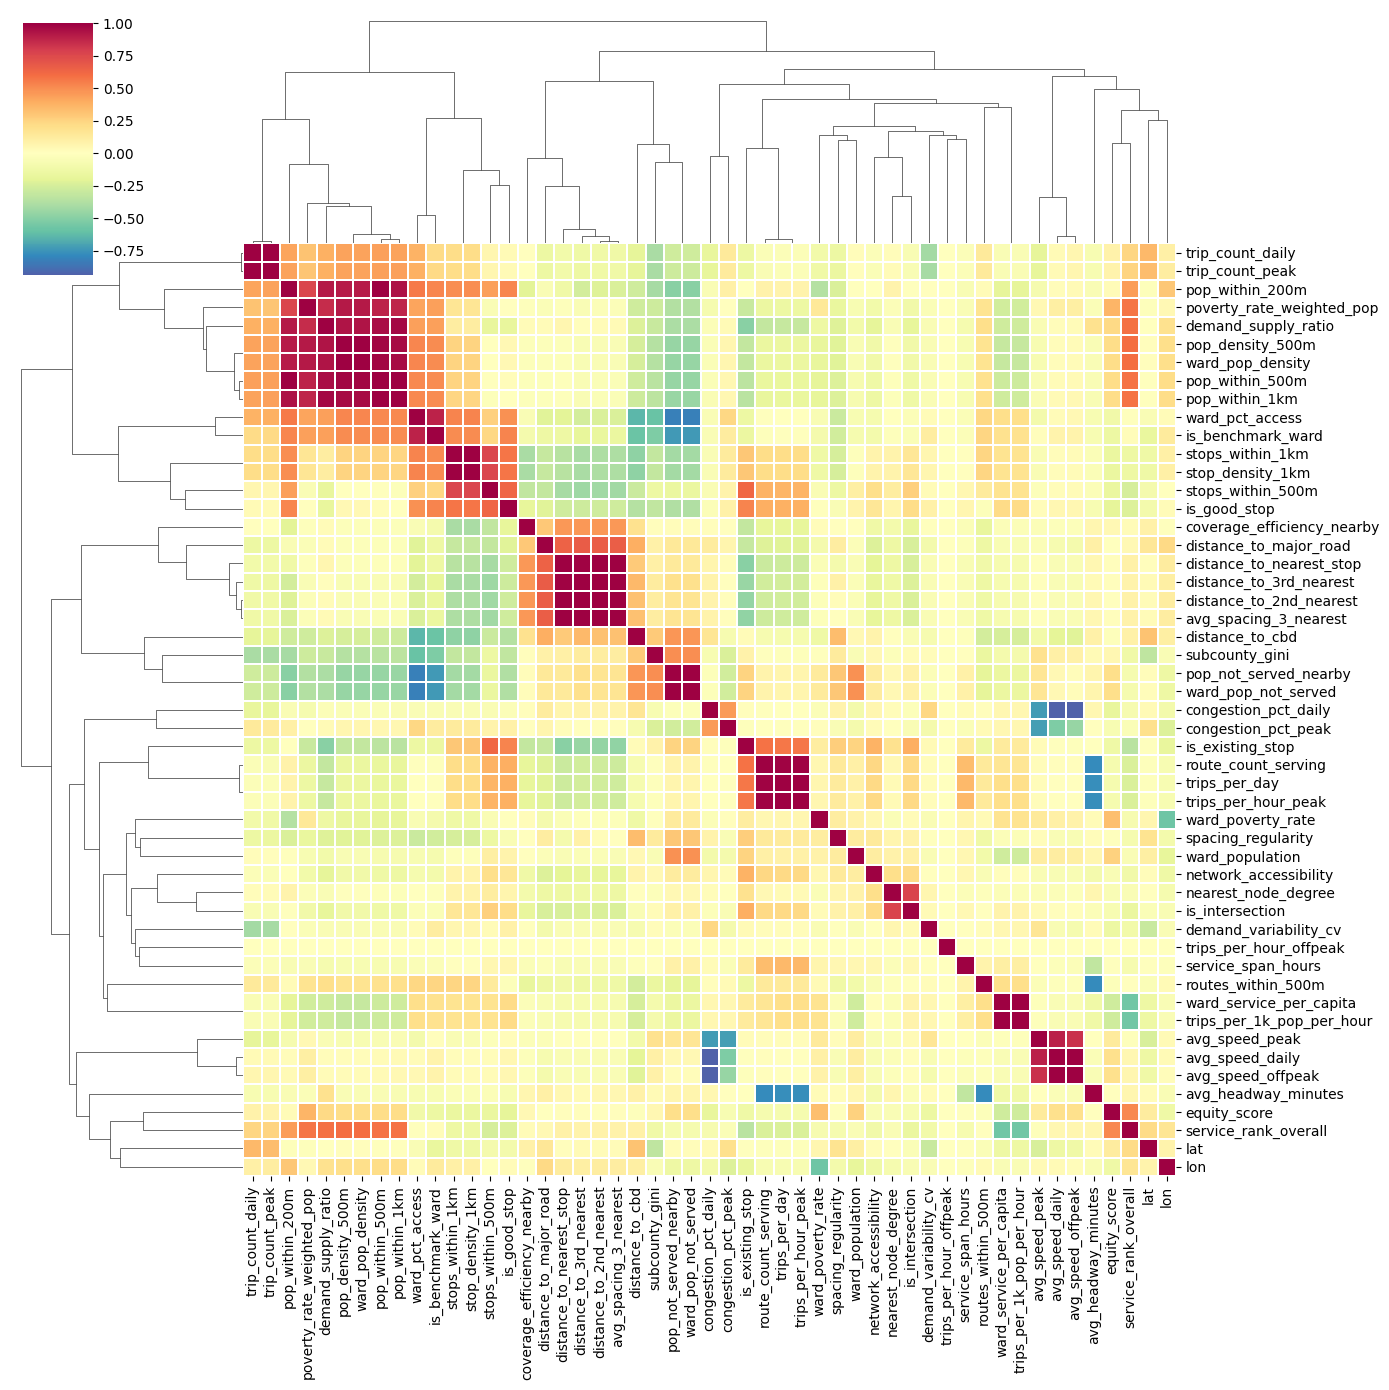

In [ ]:
# Clean correlation matrix for clustering
# Start with matrix
corr_clean = corr_matrix.copy()

# Replace inf / -inf
corr_clean = corr_clean.replace([np.inf, -np.inf], np.nan)

# Replace diagonal NaNs (sometimes appear) with 1
np.fill_diagonal(corr_clean.values, 1.0)

# Drop rows/cols that are entirely NaN
corr_clean = corr_clean.dropna(axis=0, how='all').dropna(axis=1, how='all')

# Fill remaining NaNs with 0 (neutral correlation)
corr_clean = corr_clean.fillna(0)

sns.clustermap(
    corr_clean,
    cmap='Spectral_r',
    center=0,
    figsize=(14, 14),
    linewidths=0.3
)

### vi. Correlation Network (Clean Visualization)

The raw correlation matrix is too dense for interpretation, so we visualize only
strong correlations (|r| > 0.6) using a network graph.  
Each feature becomes a node, edges represent strong correlations, node size
reflects feature connectivity (degree), and edge transparency reflects the
correlation strength.  
A force-directed layout produces a much cleaner and more readable structure.


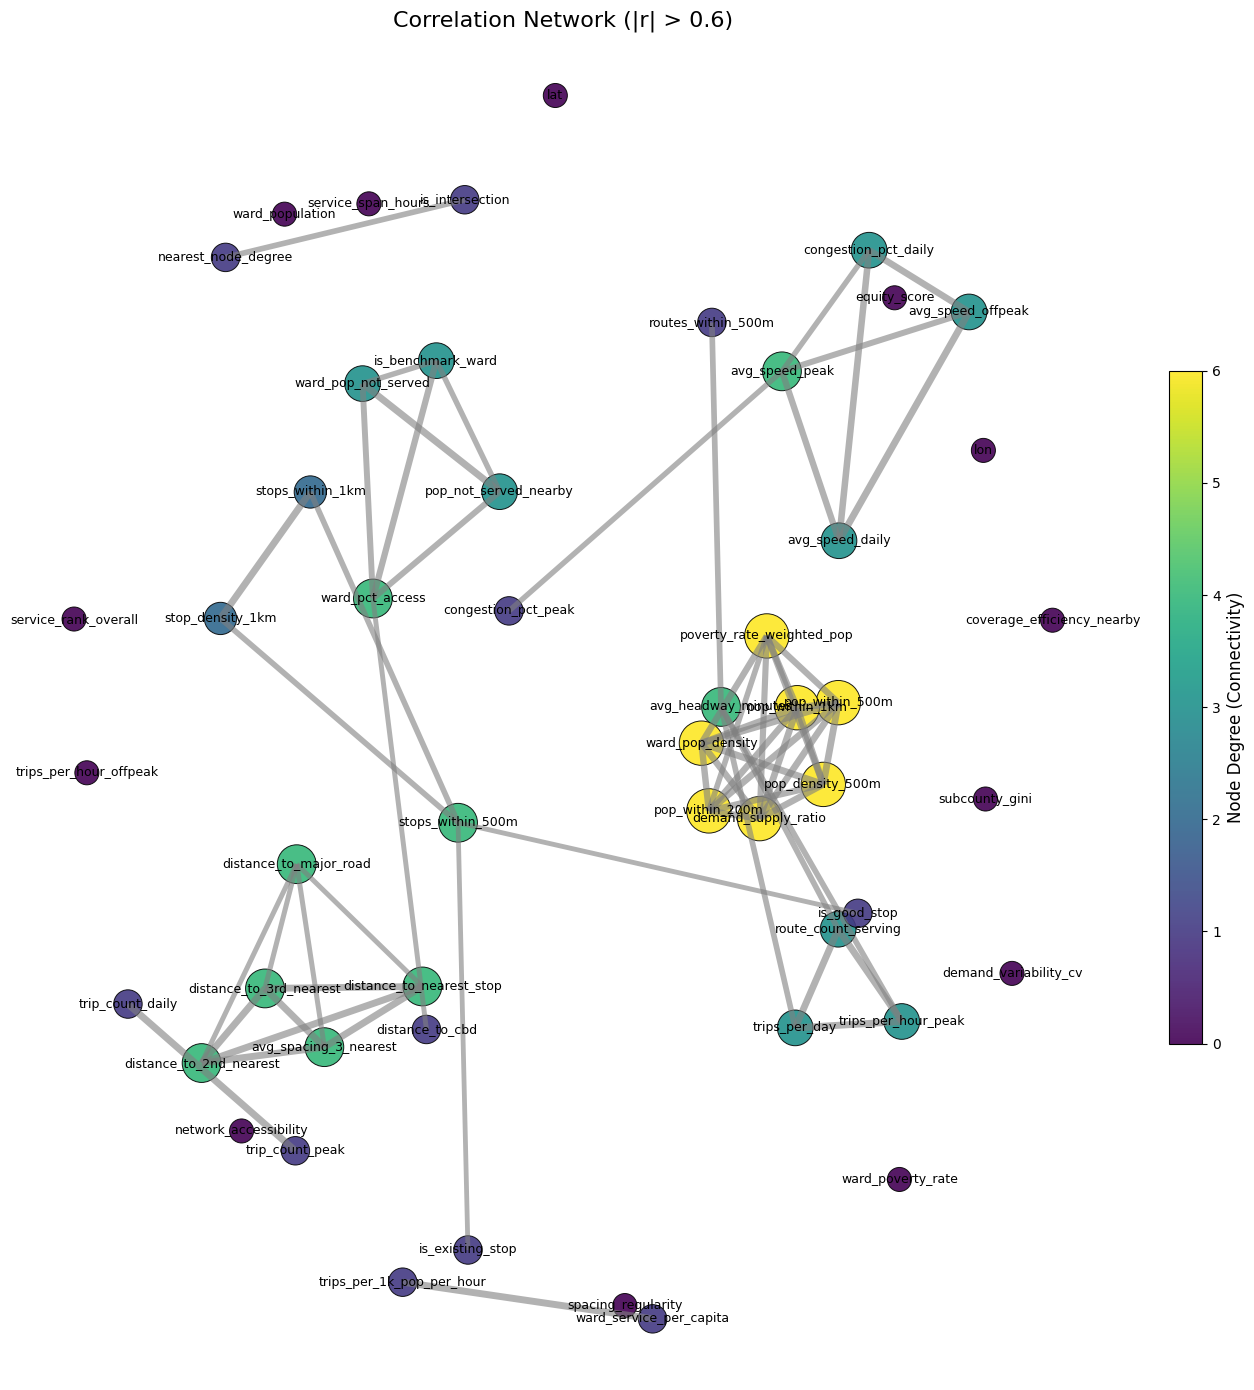

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection

THRESH = 0.6

# Build graph from correlations
G = nx.Graph()

# Add nodes
G.add_nodes_from(corr_matrix.columns)

# Add edges (only strong correlations)
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        r = corr_matrix.iloc[i, j]
        if abs(r) >= THRESH and np.isfinite(r):
            G.add_edge(corr_matrix.index[i], corr_matrix.index[j], weight=abs(r))

# Compute layout
pos = nx.spring_layout(G, seed=42, k=0.6)

# Extract edge positions
edges = []
edge_strengths = []
for u, v, d in G.edges(data=True):
    edges.append([pos[u], pos[v]])
    edge_strengths.append(d["weight"])

# Normalize strengths for linewidth
edge_widths = [1 + 4 * w for w in edge_strengths]

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(14, 14))

# Draw edges using LineCollection (simple, stable, no alpha errors)
lc = LineCollection(
    edges,
    linewidths=edge_widths,
    colors="gray",
    alpha=0.6
)
plt.gca().add_collection(lc)

# Draw nodes
degrees = dict(G.degree())
node_sizes = [300 + degrees[n] * 120 for n in G.nodes()]
node_colors = [degrees[n] for n in G.nodes()]

nodes = plt.scatter(
    [pos[n][0] for n in G.nodes()],
    [pos[n][1] for n in G.nodes()],
    s=node_sizes,
    c=node_colors,
    cmap="viridis",
    alpha=0.9,
    edgecolors="black",
    linewidths=0.7
)

# Labels
for n, (x, y) in pos.items():
    plt.text(x, y, n, fontsize=9, ha='center', va='center')

# Colorbar for node degree
cbar = plt.colorbar(nodes, shrink=0.5)
cbar.set_label("Node Degree (Connectivity)", fontsize=12)

plt.title(f"Correlation Network (|r| > {THRESH})", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()


### vii. Feature Pruning and Redundancy Reduction

To refine the dataset for modeling, we apply a structured feature-pruning step
that removes redundant, overly aggregated, or low-information variables.
The objective is to retain **high-signal, stop-level features** while eliminating
columns that either duplicate information or introduce unnecessary noise.

The pruning logic follows four main principles:

1. **Prefer stop-level, locally computed features**  
   Local metrics such as `trips_per_1k_pop_per_hour` or `pop_within_500m`
   provide much stronger granularity than ward-level aggregates like
   `ward_service_per_capita` or `ward_pop_density`.

2. **Prefer nearest / inner-buffer measurements**  
   Nearest-stop spacing and 500m population density are more predictive than
   secondary or outer-ring measures such as  
   `pop_within_1km`, `distance_to_3rd_nearest`,  
   or derived spacing metrics like `avg_spacing_3_nearest`.

3. **Remove derived, thresholded, or global summary features**  
   Binary indicators (`is_intersection`) and global ranks
   (`service_rank_overall`) compress richer numeric information already present
   in continuous features such as node degree, route counts, and service spans.

4. **Eliminate near-zero-variance or low-information columns**  
   Columns like `trips_per_hour_offpeak` contribute minimal variation and do not
   improve predictive performance.

In [ ]:
# Final curated list of dropped features
drops = [
    # Zero or low variance
    'trips_per_hour_offpeak',

    # Ward-aggregate duplicates (prefer stop-level)
    'ward_service_per_capita',
    'ward_pop_density',
    'ward_pop_not_served',

    # Nested spatial (prefer nearest / 500m)
    'distance_to_2nd_nearest',
    'distance_to_3rd_nearest',
    'avg_spacing_3_nearest',
    'spacing_regularity',
    'pop_within_1km',
    'pop_within_200m',
    'stop_density_1km',

    # Binary flags redundant with numeric columns
    'is_intersection',

    # Global or high-correlation redundant features
    'service_rank_overall',
    'pop_density_500m',
    'trips_per_hour_peak',
    'equity_score'
]

# Apply
final_df_clean = final_df1.drop(columns=drops, errors='ignore')  # Ignore if already dropped
print("Dropped cols:", [col for col in drops if col in final_df.columns])
print(f"New shape: {final_df_clean.shape}")

Dropped cols: ['trips_per_hour_offpeak', 'ward_service_per_capita', 'ward_pop_density', 'ward_pop_not_served', 'distance_to_2nd_nearest', 'distance_to_3rd_nearest', 'avg_spacing_3_nearest', 'spacing_regularity', 'pop_within_1km', 'pop_within_200m', 'stop_density_1km', 'is_intersection', 'pop_density_500m', 'trips_per_hour_peak', 'equity_score']
New shape: (8234, 40)


> Using these criteria, we consolidate all removable features into a single
drop list and prune them in one step. Afterward, we re-evaluate the correlation
structure and summary statistics of the cleaned dataset to ensure improved
feature independence and interpretability.

> This produces a compact, high-signal feature matrix better suited for downstream
modeling—particularly for graph-based architectures that benefit from clean,
non-redundant node attributes.

### viii. Post-Pruning Validation: Correlation & Summary Stats

After removing redundant features, we perform a quick diagnostic check to verify
that the cleaned dataset is well-behaved and free of excessive multicollinearity.

1. **Recompute the correlation matrix**  
   We extract only numeric columns, compute pairwise correlations, and list all
   remaining feature pairs whose absolute correlation exceeds 0.7.  
   This helps confirm whether additional pruning is needed or if the current
   feature set is sufficiently independent.

2. **Inspect descriptive statistics**  
   Using `describe()`, we review basic distributional properties of the retained
   features — ranges, means, variability — to ensure:
   - no invalid or extreme values introduced during cleaning  
   - no unexpected zero-variance columns remain  
   - population, service, density, and spatial metrics appear reasonable

In [ ]:
# Quick re-check: Remaining high corrs
num_cols_clean = final_df_clean.select_dtypes(include=[np.number]).columns
corr_matrix = final_df_clean[num_cols_clean].corr()
high_corr = corr_matrix[(abs(corr_matrix) > 0.7) & (corr_matrix != 1.0)].stack().reset_index()
high_corr.columns = ['var1', 'var2', 'corr']
high_corr = high_corr.drop_duplicates()
print("Remaining high corrs (|r| > 0.7):")
print(high_corr)

# New describe (focus on kept cols)
print("\nClean DF Describe (Key Stats):")
print(final_df_clean.describe())

Remaining high corrs (|r| > 0.7):
                         var1                       var2      corr
0           stops_within_500m           stops_within_1km  0.765401
1            stops_within_1km          stops_within_500m  0.765401
2       pop_not_served_nearby            ward_pct_access -0.819983
3   poverty_rate_weighted_pop        demand_supply_ratio  0.855371
4   poverty_rate_weighted_pop            pop_within_500m  0.880620
5         route_count_serving              trips_per_day  0.983689
6         route_count_serving        avg_headway_minutes -0.776351
7               trips_per_day        route_count_serving  0.983689
8               trips_per_day        avg_headway_minutes -0.772663
9         avg_headway_minutes        route_count_serving -0.776351
10        avg_headway_minutes              trips_per_day -0.772663
11        avg_headway_minutes         routes_within_500m -0.776351
12         routes_within_500m        avg_headway_minutes -0.776351
13            avg_speed_dail

In [ ]:
final_df_clean.to_csv('/home/dataopske/Desktop/jav/data/training_data/stop_features_training_data_16NOV.csv', index=False)

### ix. Interpretation of Remaining High-Correlation Features

After aggressive pruning, several strong correlations (|r| > 0.7) still remain.
These do **not** indicate redundancy anymore—rather, they represent meaningful
feature families that naturally co-move based on how transport systems behave.

We break them down into conceptual clusters:

**1. Stop Density Cluster**
- `stops_within_500m` ↔ `stops_within_1km` (r ≈ 0.77)

These track similar spatial density patterns at different scales.  
Both are useful: 500m captures *micro accessibility*, 1km reflects *neighborhood saturation*.

**2. Underserved Population vs Access**
- `pop_not_served_nearby` ↔ `ward_pct_access` (r ≈ –0.82)

This is expected: areas with low service access have higher numbers of
underserved residents.  
These capture **equity gaps**, a core part of your modeling objective.

**3. Population & Poverty Load Cluster**
- `poverty_rate_weighted_pop` ↔ `pop_within_500m` and `demand_supply_ratio` (r ≈ 0.85–0.95)

These represent the **demographic demand side**:
- dense areas → more people
- more people → higher poverty-weighted exposure
- higher density → higher demand relative to supply  

This family remains essential.

**4. Service Frequency Cluster**
- `route_count_serving` ↔ `trips_per_day` ↔ `avg_headway_minutes` (r ≈ ±0.77 to 0.98)
- `routes_within_500m` ↔ `avg_headway_minutes` (r ≈ –0.78)

These are inherently coupled:  
More routes → more trips → shorter headways.  
This is a fundamental property of GTFS-based service.

We intentionally keep **multiple signals** because each describes a different facet:
- service quantity (trip counts)  
- frequency (headways)  
- network richness (route count)

**5. Traffic Speed vs Congestion**
- `avg_speed_daily` ↔ `avg_speed_offpeak` (r ≈ 0.99)
- `avg_speed_daily` ↔ `congestion_pct_daily` (r ≈ –0.93)
- `avg_speed_peak` ↔ `congestion_pct_peak` (r ≈ –0.72)

Traffic layers are highly structured: speeds and congestion are inversely related.  
This is expected and meaningful—these represent **road performance** rather than redundancy.

**6. Trip Volume Cluster**
- `trip_count_daily` ↔ `trip_count_peak` (r ≈ 0.998)

Daily and peak trip counts move together strongly.  
Both remain useful:
- Daily trips capture overall demand volume.
- Peak trips capture *temporal stress* on the network.

**Overall Assessment**

The remaining correlations form **natural system clusters**, not duplicate features.
Each cluster represents a distinct transport dimension:

- **Spatial density**
- **Equity and access**
- **Population demand**
- **Service supply**
- **Road traffic performance**
- **Trip volume dynamics**

These are all essential for downstream modeling, including GNNs, because:
- GNNs rely on **feature diversity** to learn spatial-temporal patterns.
- Some multicollinearity is expected and beneficial.
- The remaining pairs no longer represent redundant columns just coupled phenomena.

> This validation step ensures the final dataset is consistent, interpretable, and
ready for downstream modeling.

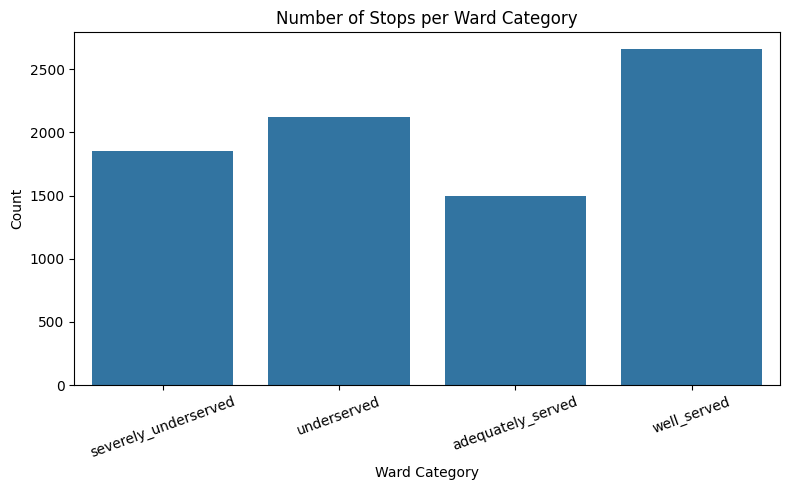

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df = final_df_clean.copy()
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='ward_category', order=[
    'severely_underserved','underserved','adequately_served','well_served'
])
plt.title("Number of Stops per Ward Category")
plt.ylabel("Count")
plt.xlabel("Ward Category")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

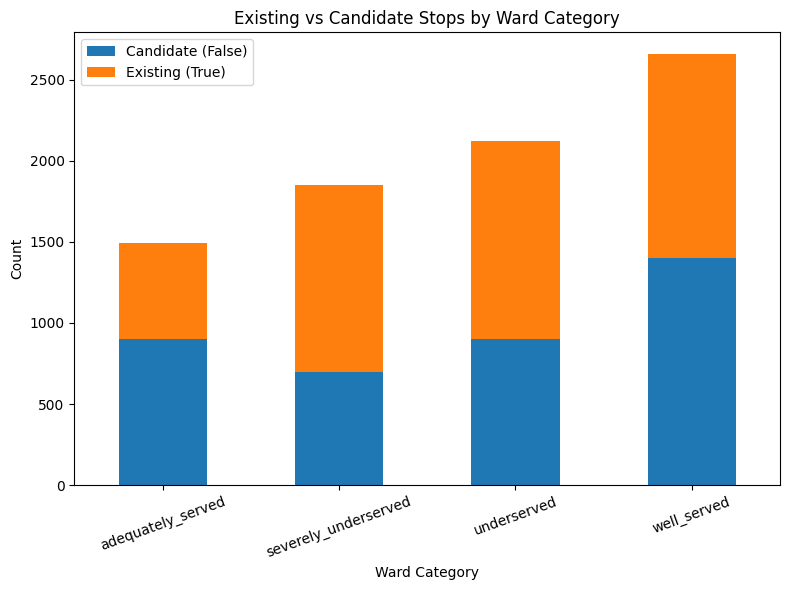

In [ ]:
import pandas as pd

category_counts = df.groupby(['ward_category', 'is_existing_stop']).size().unstack().fillna(0)

category_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(8,6)
)
plt.title("Existing vs Candidate Stops by Ward Category")
plt.ylabel("Count")
plt.xlabel("Ward Category")
plt.xticks(rotation=20)
plt.legend(["Candidate (False)", "Existing (True)"])
plt.savefig("output2.png", dpi=300, bbox_inches="tight")

plt.tight_layout()

plt.show()


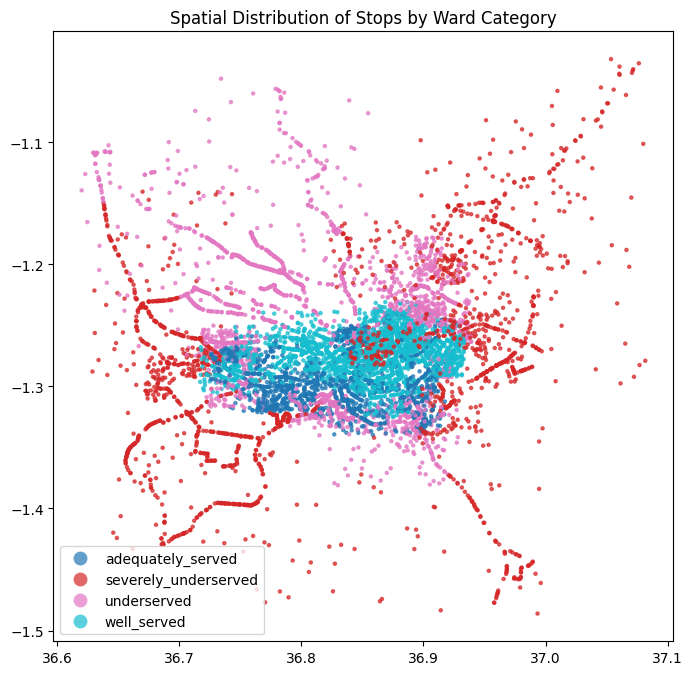

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat))

gdf.plot(
    column='ward_category',
    figsize=(8,8),
    markersize=5,
    legend=True,
    alpha=0.7
)
plt.title("Spatial Distribution of Stops by Ward Category")
plt.savefig("output.png", dpi=300, bbox_inches="tight")
plt.show()
